In [23]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak

In [24]:
f = "/home/sawini-jana/hep/MG5_aMC_v3_7_1/dihiggs_output_6.5TeV.root"
file = uproot.open(f)
print("Available keys:", file.keys())
tree_h = file["Delphes"]
f_qcd = uproot.open("/home/sawini-jana/hep/MG5_aMC_v3_7_1/qcd_output_6.5TeV.root")
tree_qcd = f_qcd["Delphes"]
print("Available keys:", f_qcd.keys())

Available keys: ['ProcessID0;1', 'Delphes;1']
Available keys: ['ProcessID0;1', 'Delphes;1']


In [25]:
branches = file['Delphes'].keys()
print(len(branches))

455


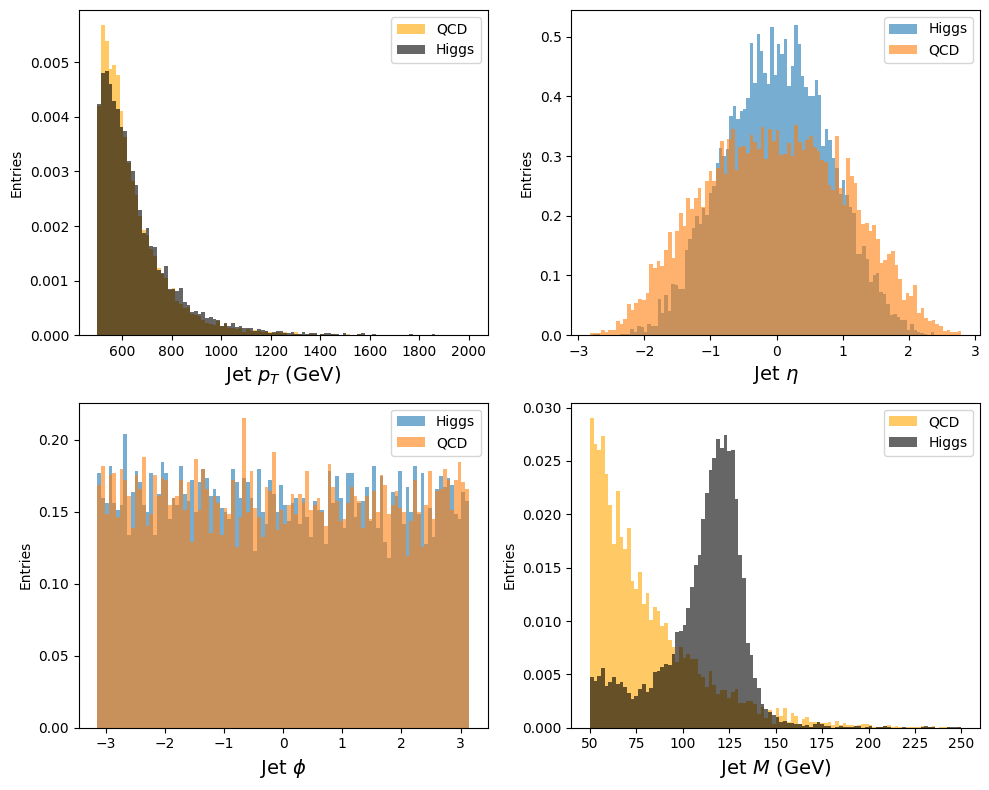

In [26]:
# %%
def get_leading_jet_obs(tree):
    pt   = tree["Jet.PT"].array()
    eta  = tree["Jet.Eta"].array()
    phi  = tree["Jet.Phi"].array()
    mass = tree["Jet.Mass"].array()

    # keep only events with at least one FatJet
    has_jet = ak.num(pt) > 0
    pt, mass, eta, phi = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet]

    #storing the leading masses
    lead_pt   = ak.to_numpy(pt[:,0])
    lead_mass = ak.to_numpy(mass[:,0])
    lead_eta = ak.to_numpy(eta[:,0])
    lead_phi = ak.to_numpy(phi[:,0])

    return lead_pt, lead_mass, lead_eta, lead_phi

jet_pt,  jet_mass, jet_eta, jet_phi = get_leading_jet_obs(tree_h)
jet_pt_qcd, jet_mass_qcd, jet_eta_qcd, jet_phi_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(jet_pt_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(500,2000), color = "orange")
axes[0,0].hist(jet_pt,bins=100, label = "Higgs", density="True", alpha=0.6, range=(500,2000), color = "Black")
axes[0,0].set_xlabel(r'Jet $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(jet_eta,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[0,1].hist(jet_eta_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[0,1].set_xlabel(r'Jet ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(jet_phi,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[1,0].hist(jet_phi_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[1,0].set_xlabel(r'Jet ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(jet_mass_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(50,250), color="orange")
axes[1,1].hist(jet_mass,bins=100, label = "Higgs", density="True", alpha=0.6, range=(50, 250), color = "black")
axes[1,1].set_xlabel(r'Jet $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

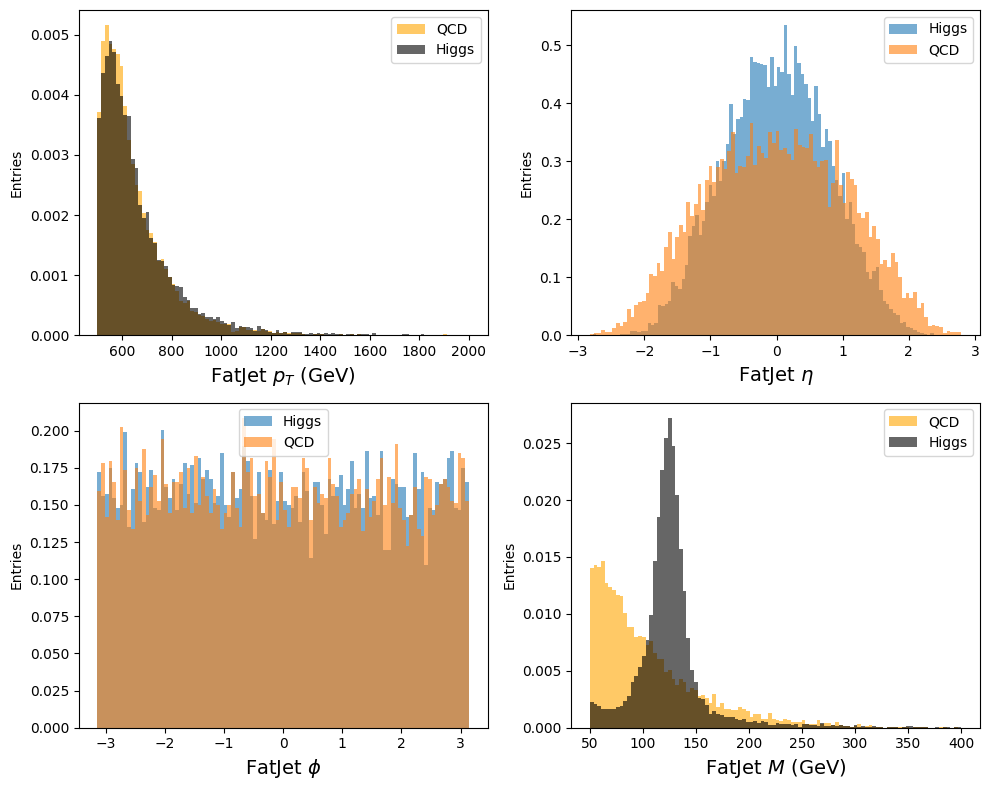

In [33]:
# %%
def get_leading_jet_obs(tree):
    pt   = tree["FatJet.PT"].array()
    eta  = tree["FatJet.Eta"].array()
    phi  = tree["FatJet.Phi"].array()
    mass = tree["FatJet.Mass"].array()

    # keep only events with at least one FatJet
    has_jet = ak.num(pt) > 0
    pt, mass, eta, phi = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet]

    #storing the leading masses
    lead_pt   = ak.to_numpy(pt[:,0])
    lead_mass = ak.to_numpy(mass[:,0])
    lead_eta = ak.to_numpy(eta[:,0])
    lead_phi = ak.to_numpy(phi[:,0])

    return lead_pt, lead_mass, lead_eta, lead_phi

jet_pt,  jet_mass, jet_eta, jet_phi = get_leading_jet_obs(tree_h)
jet_pt_qcd, jet_mass_qcd, jet_eta_qcd, jet_phi_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(jet_pt_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(500,2000), color = "orange")
axes[0,0].hist(jet_pt,bins=100, label = "Higgs", density="True", alpha=0.6, range=(500,2000), color = "Black")
axes[0,0].set_xlabel(r'FatJet $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(jet_eta,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[0,1].hist(jet_eta_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[0,1].set_xlabel(r'FatJet ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(jet_phi,bins=100, label = "Higgs", density="True", alpha=0.6)
axes[1,0].hist(jet_phi_qcd,bins=100, label = "QCD", density="True", alpha=0.6)
axes[1,0].set_xlabel(r'FatJet ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(jet_mass_qcd,bins=100, label = "QCD", density="True", alpha=0.6, range=(50,400), color="orange")
axes[1,1].hist(jet_mass,bins=100, label = "Higgs", density="True", alpha=0.6, range=(50, 400), color = "black")
axes[1,1].set_xlabel(r'FatJet $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

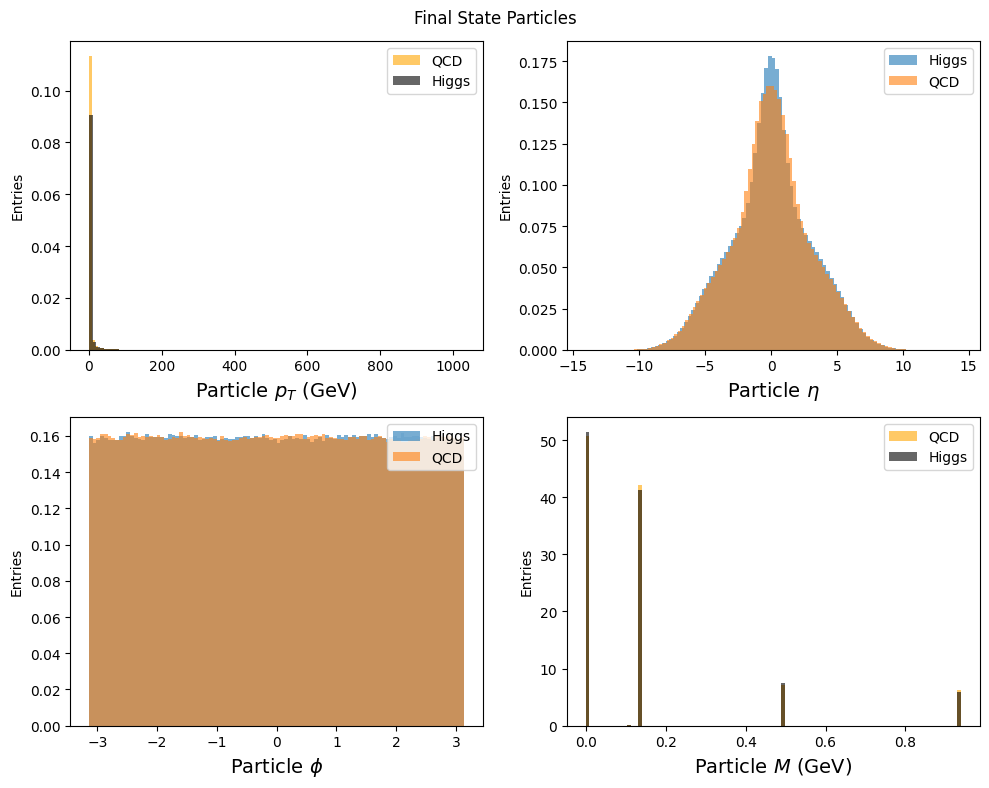

In [28]:
# %%
def get_leading_jet_obs(tree):
    pt   = ak.flatten(tree["Particle.PT"].array())
    eta  = ak.flatten(tree["Particle.Eta"].array())
    phi  = ak.flatten(tree["Particle.Phi"].array())
    mass = ak.flatten(tree["Particle.Mass"].array())

    # keep only events with at least one FatJet
    has_jet = (ak.flatten(tree["Particle.Status"] .array()) == 1) & (pt>0)
    final_pt, final_mass, final_eta, final_phi = pt[has_jet], mass[has_jet], eta[has_jet], phi[has_jet]

    return final_pt, final_mass, final_eta, final_phi

part_pt,  part_mass, part_eta, part_phi = get_leading_jet_obs(tree_h)
part_pt_qcd, part_mass_qcd, part_eta_qcd, part_phi_qcd = get_leading_jet_obs(tree_qcd)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Final State Particles")

axes[0,0].hist(part_pt_qcd,bins=100, label = "QCD", density=True, alpha=0.6, color = "orange")
axes[0,0].hist(part_pt,bins=100, label = "Higgs", density=True, alpha=0.6,color = "Black")
axes[0,0].set_xlabel(r'Particle $p_T$ (GeV)',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(part_eta,bins=100, label = "Higgs", density=True, alpha=0.6)
axes[0,1].hist(part_eta_qcd,bins=100, label = "QCD", density=True, alpha=0.6)
axes[0,1].set_xlabel(r'Particle ${\eta}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(part_phi,bins=100, label = "Higgs", density=True, alpha=0.6)
axes[1,0].hist(part_phi_qcd,bins=100, label = "QCD", density=True, alpha=0.6)
axes[1,0].set_xlabel(r'Particle ${\phi}$',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(part_mass_qcd,bins=100, label = "QCD", density=True, alpha=0.6, color="orange")
axes[1,1].hist(part_mass,bins=100, label = "Higgs", density=True, alpha=0.6, color = "black")
axes[1,1].set_xlabel(r'Particle $M$ (GeV)',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Observable Analysis

In [29]:
import pandas as pd

file = open("/home/sawini-jana/hep/pythia8316/coding/observables_6.5TeV.csv", "r", newline='')
df = pd.read_csv(file)

print(df['phi1'][0:5] + 1)
print(df.loc[10:12]['phi2'])

higgs = df[df.label==1][['phi1', 'phi2', 'phi3', 'phi4']].values
qcd = df[df.label==0][['phi1', 'phi2', 'phi3', 'phi4']].values
print(higgs)

0    1.015007
1    1.051110
2    1.040309
3    1.019796
4    1.053053
Name: phi1, dtype: float64
10    0.223921
11    0.126828
12    0.236820
Name: phi2, dtype: float64
[[0.0150066  0.221715   0.121281   0.00351593]
 [0.0511103  0.188993   0.126984   0.00303093]
 [0.040309   0.282647   0.164083   0.00518272]
 ...
 [0.0370169  0.264933   0.141866   0.00417021]
 [0.00366164 0.128228   0.0887255  0.00135113]
 [0.0713092  0.259375   0.135895   0.00183859]]


In [30]:
qcd = qcd[int(len(qcd)/4):int(3*len(qcd)/4)]
print(len(higgs)+len(qcd))
print(len(qcd)/len(higgs)) #20:80 ratio

2131
0.6819258089976322


In [31]:
import numpy as np

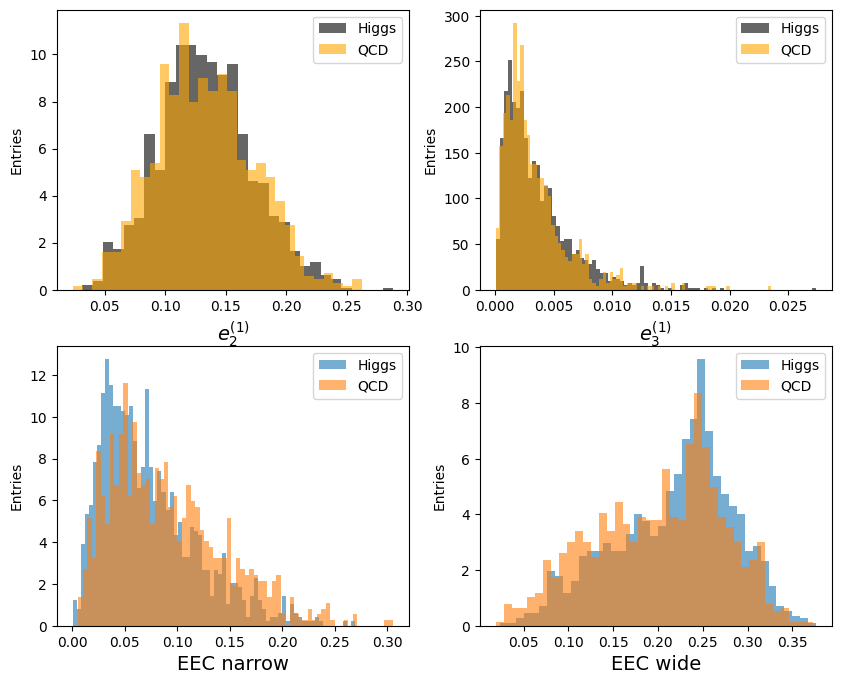

In [39]:
import matplotlib.pyplot as plt

#HIGGS
EECnarrow_h = higgs[:,0]
EECwide_h = higgs[:,1]
ecf2_h = higgs[:,2]
ecf3_h = higgs[:,3]

#QCD
EECnarrow_qcd = qcd[:,0]
EECwide_qcd = qcd[:,1]
ecf2_qcd = qcd[:,2]
ecf3_qcd = qcd[:,3]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(ecf2_h, bins=30, density=True, alpha=0.6, label="Higgs", color="black")
axes[0,0].hist(ecf2_qcd, bins=30, density=True, alpha=0.6, label="QCD", color="orange")
axes[0,0].set_xlabel(r'$e_2^{(1)}$',fontsize=14)
axes[0,0].set_ylabel("Entries")
axes[0,0].legend()

axes[0,1].hist(ecf3_h, bins=80, density=True, alpha=0.6, label="Higgs", color="black")
axes[0,1].hist(ecf3_qcd, bins=80, density=True, alpha=0.6, label="QCD", color ="orange")
axes[0,1].set_xlabel(r'$e_3^{(1)}$',fontsize=14)
axes[0,1].set_ylabel("Entries")
axes[0,1].legend()

axes[1,0].hist(EECnarrow_h, bins=70, density=True, alpha=0.6, label="Higgs")
axes[1,0].hist(EECnarrow_qcd, bins=70, density=True, alpha=0.6, label="QCD")
axes[1,0].set_xlabel(r'EEC narrow',fontsize=14)
axes[1,0].set_ylabel("Entries")
axes[1,0].legend()

axes[1,1].hist(EECwide_h, bins=40, density=True, alpha=0.6, label="Higgs")
axes[1,1].hist(EECwide_qcd, bins=40, density=True, alpha=0.6, label="QCD")
axes[1,1].set_xlabel(r'EEC wide',fontsize=14)
axes[1,1].set_ylabel("Entries")
axes[1,1].legend()

plt.show()